## Preliminary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./FWSL25_matches.csv')

In [2]:
df.shape

(1621, 89)

In [3]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns#all numeric columns
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']# numeric columns of high interest
intensity_metrics =['player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio','max_acceleration_mss','max_deceleration_mss']
volume_metrics = ['distance_km','sprint_distance_m','power_plays','energy_kcal','impacts']


In [4]:
df['match_day'] = df['match_day'].str.replace('Wmd', 'MD')

In [5]:
from IPython.display import HTML

def style_table_for_docs(df, hide_index=False):
    styled = (
        df.style
        .set_properties(**{
            'color': 'black',
            'background-color': 'white',
            'border': '1px solid black',
            'text-align': 'center',
            'padding': '2px'  # reduces row height
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')  # also reduce header row height
            ]},
            {'selector': 'td', 'props': [
                ('color', 'black'), 
                ('border', '1px solid black'),
                ('padding', '2px')
            ]},
            {'selector': 'table', 'props': [
                ('border', '2px solid black'), 
                ('border-collapse', 'collapse')
            ]}
        ])
    )
    
    if hide_index:
        styled = styled.hide(axis='index')

    return styled


In [6]:
df['total_accelerations'] = df[
	[
		'accelerations_zone_count:_1__2_mss',
		'accelerations_zone_count:_2__3_mss',
		'accelerations_zone_count:_3__4_mss',
		'accelerations_zone_count:_>_4_mss'
	]
].sum(axis=1)

df['total_decelerations'] = df[
	[
		'deceleration_zone_count:_1__2_mss',
		'deceleration_zone_count:_2__3_mss',
		'deceleration_zone_count:_3__4_mss',
		'deceleration_zone_count:_>_4_mss'
	]
].sum(axis=1)


In [7]:
volume_metrics.append('total_accelerations')
volume_metrics.append('total_decelerations')

df['acc_counts_per_min'] = df['total_accelerations'] / df['duration']
df['dec_counts_per_min'] = df['total_decelerations'] / df['duration']

intensity_metrics.append('acc_counts_per_min')
intensity_metrics.append('dec_counts_per_min')

## Executive Summary

In [8]:
summary_table_intensity = df[intensity_metrics].agg(['max', 'mean', 'std']).T
style_table_for_docs(summary_table_intensity)

,max,mean,std
player_load,593.191200,360.131328,94.296341
top_speed_kmh,31.168200,25.609207,2.012019
distance_per_min_mmin,116.958686,74.571150,19.871926
power_score_wkg,18.785700,11.564177,3.129363
work_ratio,101.923800,58.936901,17.582025
max_acceleration_mss,10.000000,5.216721,0.562937
max_deceleration_mss,10.000000,6.427612,0.951955
acc_counts_per_min,5.960811,3.559783,1.010443
dec_counts_per_min,5.826271,3.456189,0.994023


In [9]:
summary_table_volume = df[volume_metrics].agg(['sum', 'max','mean', 'std']).T
style_table_for_docs(summary_table_volume.round(2))

,sum,max,mean,std
distance_km,11939.640000,11.260000,7.370000,1.970000
sprint_distance_m,691564.900000,1279.410000,426.630000,219.980000
power_plays,60773.000000,97.000000,37.490000,15.250000
energy_kcal,1179427.750000,1334.900000,727.590000,208.730000
impacts,9182.000000,44.000000,5.660000,5.560000
total_accelerations,569844.000000,601.000000,351.540000,100.020000
total_decelerations,553253.000000,586.000000,341.300000,98.390000


In [10]:
distance_speed_zones = ['distance_in_speed_zone_1_km', 'distance_in_speed_zone_2_km', 'distance_in_speed_zone_3_km','distance_in_speed_zone_4_km','distance_in_speed_zone_5_km']
for i in distance_speed_zones:
    df[i] = df[i] * 1000  # Convert from km to m

speed_zone_dist= df[distance_speed_zones].agg(['sum','max', 'mean', 'std']).T.round(2)
style_table_for_docs(speed_zone_dist)

,sum,max,mean,std
distance_in_speed_zone_1_km,1565914.600000,1872.200000,966.020000,271.590000
distance_in_speed_zone_2_km,6456455.700000,6062.300000,3983.010000,1088.840000
distance_in_speed_zone_3_km,3225711.000000,4494.400000,1989.950000,733.140000
distance_in_speed_zone_4_km,656076.600000,1225.000000,404.740000,200.410000
distance_in_speed_zone_5_km,35483.100000,295.300000,21.890000,32.610000


## Data Overview

In [11]:
unique_players_per_club = df.groupby('club_for')['p_name'].nunique().reset_index()
unique_players_per_club.columns = ['club_for', 'unique_players']
style_table_for_docs(unique_players_per_club.sort_values(by='unique_players', ascending=False))

,club_for,unique_players
8,She Maroons Fc,23
2,Kawempe Muslim Lfc,20
1,Kampala Queens Fc,20
0,Amus College Wfc,19
9,Uganda Martyrs Lubaga Wfc,18
4,Makerere University Wfc,17
3,Lady Doves Fc,16
10,Wakiso Hill Wfc,16
6,Rines Ss Wfc,16
5,Olila Hs Wfc,12


In [12]:
players_match_days = df.groupby(['p_name', 'player_club_'])['match_day'].nunique().reset_index()
players_match_days.columns = ['p_name', 'player_club_', 'unique_match_days']
style_table_for_docs(players_match_days.sort_values(by='unique_match_days', ascending=False).head(10))

,p_name,player_club_,unique_match_days
154,Samalie Nakacwa,Kawempe Muslim Lfc,19
164,Sharifah Nakimera,Kawempe Muslim Lfc,19
83,Joweria Babirye,She Maroons Fc,19
3,Agnes Nabukenya,Kawempe Muslim Lfc,17
81,Jovia Nakirya,Rines Ss Wfc,17
78,Jolly Kobusinge,Kawempe Muslim Lfc,17
155,Shadia Nabirye,Kawempe Muslim Lfc,17
96,Latifah Nakasi,Uganda Martyrs Lubaga Wfc,17
65,Hilati Kaudha,Rines Ss Wfc,17
31,Comfort Aculu,Uganda Martyrs Lubaga Wfc,17


In [13]:
# Calculate average number of unique players per matchday for each club
players_per_club_day = df.groupby(['club_for', 'match_day'])['p_name'].nunique().reset_index()
avg_players_per_matchday = players_per_club_day.groupby('club_for')['p_name'].mean().reset_index()
avg_players_per_matchday.columns = ['club_for', 'avg_players_per_matchday']
style_table_for_docs(avg_players_per_matchday.sort_values(by='avg_players_per_matchday', ascending=False))

,club_for,avg_players_per_matchday
8,She Maroons Fc,12.052632
4,Makerere University Wfc,11.571429
10,Wakiso Hill Wfc,11.250000
2,Kawempe Muslim Lfc,11.105263
0,Amus College Wfc,11.000000
9,Uganda Martyrs Lubaga Wfc,10.411765
6,Rines Ss Wfc,10.294118
1,Kampala Queens Fc,9.454545
5,Olila Hs Wfc,7.272727
7,She Corporates Fc,6.666667


In [14]:
# Count the number of unique matchdays for each club
unique_matchdays_per_club = df.groupby('club_for')['match_day'].nunique().reset_index()
unique_matchdays_per_club.columns = ['club_for', 'unique_matchdays']
style_table_for_docs(unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False))

,club_for,unique_matchdays
2,Kawempe Muslim Lfc,19
8,She Maroons Fc,19
0,Amus College Wfc,17
9,Uganda Martyrs Lubaga Wfc,17
6,Rines Ss Wfc,17
10,Wakiso Hill Wfc,16
3,Lady Doves Fc,14
4,Makerere University Wfc,14
1,Kampala Queens Fc,11
5,Olila Hs Wfc,11


C:\Users\hnyanzi\AppData\Local\Temp\ipykernel_14616\1451582924.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)


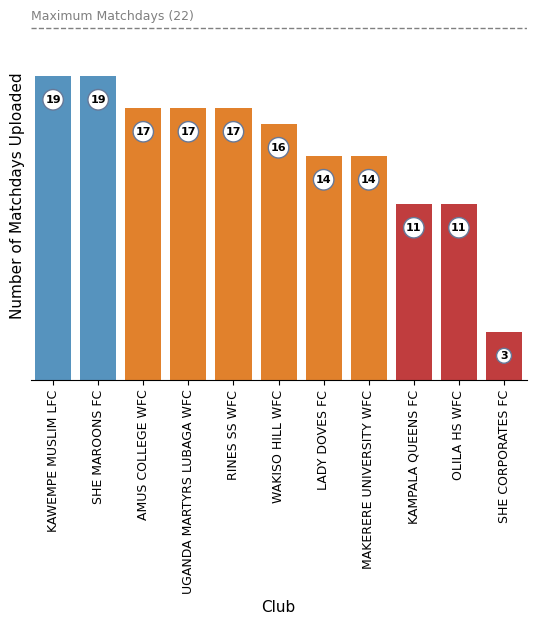

In [47]:
# Sort data
data = unique_matchdays_per_club.sort_values(by='unique_matchdays', ascending=False)

# Define usage tiers and corresponding colors
def usage_tier_color(val):
    if val >= 18:
        return "#4596cf"  # dark blue for high engagement
    elif val >= 13:
        return '#ff7f0e'  # orange for medium
    else:
        return '#d62728'  # red for low

colors = data['unique_matchdays'].map(usage_tier_color).tolist()

# Create barplot
# plt.figure(figsize=(12,6))
sns.barplot(data=data, x='club_for',hue='club_for', y='unique_matchdays', palette=colors,legend=False)

# Benchmark line at maximum matchdays (22)
plt.axhline(22, color='gray', linestyle='--', linewidth=1)
plt.text(-0.5, 22.5, 'Maximum Matchdays (22)', color='gray', fontsize=9)

# Rotate and uppercase x labels
ax = plt.gca()
ax.set_xticklabels([lbl.get_text().upper() for lbl in ax.get_xticklabels()], rotation=90, fontsize=9)

# Title, subtitle, and axis labels
plt.xlabel('Club', fontsize=11)
plt.ylabel('Number of Matchdays Uploaded', fontsize=11)

# Gridlines for y-axis
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Annotate values inside bars
for i, value in enumerate(data['unique_matchdays']):
    ax.text(
        i, value - 1.8, str(value),
        ha='center', va='bottom',
        fontsize=8, color='black', fontweight='bold',
        bbox=dict(boxstyle="circle,pad=0.22", edgecolor='#667898', facecolor='white', linewidth=1)
    )
#remove yaxis ticklabels
ax.set_yticklabels([])
ax.set_yticks([])


plt.show()


In [16]:
# Calculate total player entries per matchday across all clubs
total_players_per_matchday = df.groupby('match_day')['p_name'].count().reset_index()
total_players_per_matchday.columns = ['match_day', 'total_player_entries']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'MD{i}' for i in range(1, 23)]
total_players_per_matchday['match_day'] = pd.Categorical(
    total_players_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(total_players_per_matchday.sort_values(by='match_day'))

,match_day,total_player_entries
0,MD1,67
11,MD2,79
15,MD3,80
16,MD4,101
17,MD5,64
18,MD6,94
19,MD7,112
20,MD8,77
21,MD9,74
1,MD10,91


In [17]:
# Count the number of unique clubs that submitted data per matchday
clubs_per_matchday = df.groupby('match_day')['club_for'].nunique().reset_index()
clubs_per_matchday.columns = ['match_day', 'num_clubs']
# Ensure 'match_day' is a categorical variable with the correct order
matchday_order = [f'MD{i}' for i in range(1, 31)]
clubs_per_matchday['match_day'] = pd.Categorical(
    clubs_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
style_table_for_docs(clubs_per_matchday.sort_values(by='match_day'))


,match_day,num_clubs
0,MD1,6
11,MD2,8
15,MD3,7
16,MD4,9
17,MD5,6
18,MD6,8
19,MD7,11
20,MD8,8
21,MD9,7
1,MD10,9


In [48]:

def plot_line_with_values(data, x_col, y_col, title=None, x_label=None,y_label=None, figsize=(10, 6)):
    # Create figure and axis
    plt.figure(figsize=figsize)
    
    # Plot the line
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)

    
    # Get current axis
    ax = plt.gca()
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set spine and tick colors to light gray
    gray_color = '#808080'
    ax.spines['bottom'].set_color(gray_color)
    ax.spines['left'].set_color(gray_color)
    

    if x_col == 'match_day':
        # Ensure match_day is ordered as per matchday_order
        data[x_col] = pd.Categorical(data[x_col], categories=matchday_order, ordered=True)
        data_sorted = data.sort_values(by=x_col)
        xticklabels = [str(Wmd).replace('Wmd', 'Wmd ') for Wmd in data_sorted[x_col]]
        ax.set_xticks(range(len(data_sorted[x_col])))
        ax.set_xticklabels(xticklabels, rotation=90)
        # Re-plot with sorted data to ensure correct order
        
        sns.lineplot(data=data_sorted, x=x_col, y=y_col, marker='o', color='orange', linewidth=2)
        
    # Add value labels above each point
    for i, (x, y) in enumerate(zip(data[x_col], data[y_col])):
        ax.annotate(
            f'{y}', 
            (x, y),
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center',
            fontsize=8,
            bbox=dict(boxstyle="circle,pad=0.35", edgecolor='#FE912A', facecolor='white', linewidth=1)
        )
    
    # Set title
    if title is None:
        title = f'{y_col} vs {x_col}'
    plt.title(title)

    # #start the y-axis at 0
    ax.set_ylim(bottom=2,top=14)  # Adjust the top limit as needed
    

    # Set labels
    if x_label is None:
        x_label = x_col.replace('_', ' ').title()
    plt.xlabel(x_label)
    if y_label is None:
        y_label = y_col.replace('_', ' ').title()
    plt.ylabel(y_label)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, color='#E0DCDD', alpha=0.7)
    # Adjust layout
    plt.tight_layout()
    
    return ax

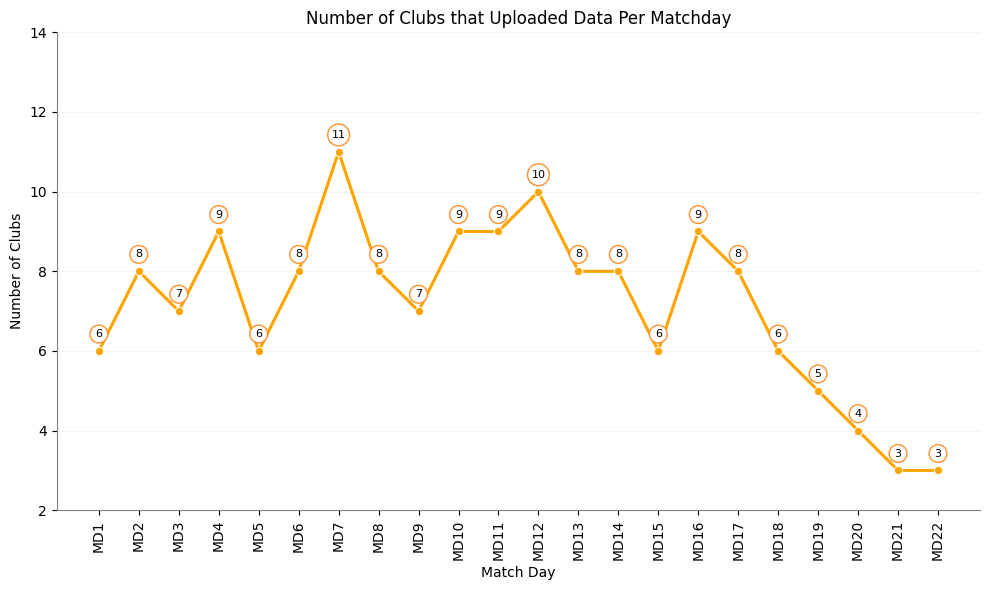

In [49]:
plot_line_with_values(clubs_per_matchday, 'match_day', 'num_clubs', title='Number of Clubs that Uploaded Data Per Matchday',x_label='Match Day', y_label='Number of Clubs');

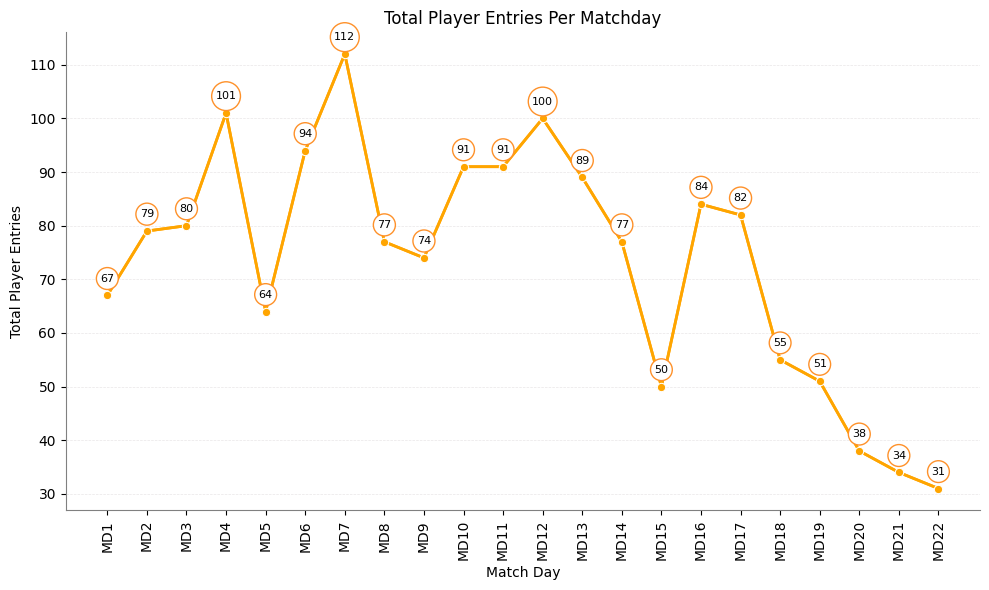

In [20]:
plot_line_with_values(total_players_per_matchday, 'match_day', 'total_player_entries', title='Total Player Entries Per Matchday', x_label='Match Day', y_label='Total Player Entries');

In [21]:
# Count number and percentage of entries based on 'location'
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,location,count,percentage
0,Home,887,54.719309
1,Away,734,45.280691


In [22]:
# Count number and percentage of entries based on 'result'
location_counts = df['result'].value_counts().reset_index()
location_counts.columns = ['result', 'count']
location_counts['percentage'] = (location_counts['count'] / len(df)) * 100

style_table_for_docs(location_counts)

,result,count,percentage
0,Win,595,36.705737
1,Draw,559,34.484886
2,Loss,467,28.809377


In [23]:
# Calculate Win-Draw-Loss counts for each club using unique match days
matchday_results = df.groupby(['club_for', 'match_day'])['result'].first().reset_index()
wld_counts = matchday_results.groupby(['club_for', 'result']).size().unstack(fill_value=0)
wld_counts = wld_counts[['Win', 'Draw', 'Loss']]  # Ensure order if all present

style_table_for_docs(wld_counts.sort_values(by='Win', ascending=False))


result,Win,Draw,Loss
club_for,,,
Kawempe Muslim Lfc,9,6,4
Amus College Wfc,8,7,2
Lady Doves Fc,7,2,5
She Maroons Fc,7,7,5
Kampala Queens Fc,6,5,0
Rines Ss Wfc,6,4,7
Makerere University Wfc,6,6,2
Uganda Martyrs Lubaga Wfc,5,5,7
Olila Hs Wfc,3,6,2


### Max Metrics

In [24]:
speed_table = df[['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']].agg(['max', 'mean', 'std']).T
style_table_for_docs(speed_table)

,max,mean,std
top_speed_kmh,31.168200,25.609207,2.012019
distance_per_min_mmin,116.958686,74.571150,19.871926
max_acceleration_mss,10.000000,5.216721,0.562937
max_deceleration_mss,10.000000,6.427612,0.951955


## Analysis

### Club Comparison

In [25]:
club_volume_mean = (
    df.groupby(['club_for', 'match_day'],observed=False)[volume_metrics].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_distance_km', ascending=False)
    .reset_index()
)
club_volume_mean.round(2)
style_table_for_docs(club_volume_mean)


,club_for,avg_distance_km,avg_sprint_distance_m,avg_power_plays,avg_energy_kcal,avg_impacts,avg_total_accelerations,avg_total_decelerations
0,Olila Hs Wfc,8.381743,486.317372,41.781782,815.533547,3.807792,383.448449,372.129654
1,Lady Doves Fc,8.030605,504.100178,42.244048,737.090414,6.427636,367.137925,359.151531
2,Amus College Wfc,7.757532,511.149800,42.421443,762.107678,7.086354,366.274723,355.974970
3,She Corporates Fc,7.632197,382.682867,36.822222,648.701368,2.472222,348.905556,339.005556
4,Uganda Martyrs Lubaga Wfc,7.615300,418.294654,36.397029,720.831062,6.120945,356.735220,344.108348
5,Rines Ss Wfc,7.447425,399.232173,35.392225,748.148628,5.012248,360.782093,351.458381
6,Kawempe Muslim Lfc,7.400494,448.859131,39.124803,727.785441,4.003470,345.943606,336.197876
7,Kampala Queens Fc,7.388725,421.845977,38.367532,717.817596,6.214935,369.477023,357.108576
8,Makerere University Wfc,7.222302,369.377179,35.044503,686.126930,5.963203,338.904002,331.147849
9,Wakiso Hill Wfc,7.064959,338.150639,32.442133,642.408728,7.060237,365.790603,352.325086


In [26]:
club_intensity_mean = (
    df.groupby(['club_for', 'match_day'])[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
    .groupby('club_for').mean()
    .rename(columns=lambda x: f'avg_{x}')
    .sort_values(by='avg_work_ratio', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_mean)

,club_for,avg_player_load,avg_power_score_wkg,avg_work_ratio,avg_acc_counts_per_min,avg_dec_counts_per_min
0,Olila Hs Wfc,381.913963,13.268352,69.188270,3.921781,3.806096
1,Lady Doves Fc,393.466447,12.668525,63.355147,3.770569,3.688756
2,Amus College Wfc,382.605996,11.933591,61.757213,3.618006,3.516274
3,Kawempe Muslim Lfc,345.681613,11.969431,61.344035,3.600752,3.499445
4,Rines Ss Wfc,362.341275,11.686114,59.909847,3.678845,3.583307
5,She Corporates Fc,347.584038,11.995852,59.616496,3.546321,3.445666
6,Uganda Martyrs Lubaga Wfc,377.404749,11.554225,58.649001,3.516097,3.391480
7,Kampala Queens Fc,377.404023,11.734040,58.368970,3.764821,3.639287
8,Wakiso Hill Wfc,360.577511,11.092608,56.825906,3.694816,3.558883
9,She Maroons Fc,334.289822,10.917186,55.222304,3.307986,3.226335


In [27]:
club_intensity_max = (
    df.groupby('club_for')[['top_speed_kmh', 'distance_per_min_mmin', 'max_acceleration_mss', 'max_deceleration_mss']]
    .max()
    .rename(columns=lambda x: f'max_{x}')
    .sort_values(by='max_top_speed_kmh', ascending=False)
    .reset_index()
)
style_table_for_docs(club_intensity_max)

,club_for,max_top_speed_kmh,max_distance_per_min_mmin,max_max_acceleration_mss,max_max_deceleration_mss
0,Kampala Queens Fc,31.168200,100.490426,7.248900,9.070400
1,Kawempe Muslim Lfc,31.168200,115.154725,10.000000,10.000000
2,She Maroons Fc,30.608200,116.958686,6.848900,10.000000
3,Amus College Wfc,30.456200,111.916667,7.244500,9.200100
4,Uganda Martyrs Lubaga Wfc,30.448200,102.605704,6.200100,10.000000
5,Lady Doves Fc,30.408200,111.855057,7.086900,9.444500
6,Rines Ss Wfc,30.336200,113.497779,6.774100,10.000000
7,Olila Hs Wfc,29.856200,111.068931,6.333400,9.440800
8,Wakiso Hill Wfc,29.568200,105.418876,7.385200,9.231200
9,Makerere University Wfc,29.152200,106.039501,6.374100,9.704800


### Player High Scores

In [28]:
# For each metric in volume_metrics, find the player with the highest value, the value, and the club
top_players = []
for metric in volume_metrics +intensity_metrics:
    idx = df[metric].idxmax()
    row = df.loc[idx]
    top_players.append({
        'metric': metric,
        'player': row['p_name'],
        'club': row['club_for'],
        'value': row[metric],
        'match day': row['match_day']
    })

top_players_df = pd.DataFrame(top_players)
style_table_for_docs(top_players_df)

,metric,player,club,value,match day
0,distance_km,Irene Nantege,Lady Doves Fc,11.261000,MD11
1,sprint_distance_m,Joyce Kainza,Amus College Wfc,1279.411000,MD9
2,power_plays,Joyce Kainza,Amus College Wfc,97.000000,MD9
3,energy_kcal,Jackeline Adong,She Maroons Fc,1334.901400,MD20
4,impacts,Yasmeen Nalukwago,Rines Ss Wfc,44.000000,MD17
5,total_accelerations,Immaculate Nakanjako,Uganda Martyrs Lubaga Wfc,601.000000,MD2
6,total_decelerations,Phionah Arach,Rines Ss Wfc,586.000000,MD17
7,player_load,Catherine Namataka,Amus College Wfc,593.191200,MD13
8,top_speed_kmh,Jovia Nakagolo,Kawempe Muslim Lfc,31.168200,MD16
9,distance_per_min_mmin,Jackeline Adong,She Maroons Fc,116.958686,MD20


### Comparison by Position Group

In [29]:
# Calculate average volume metrics by general position
avg_volume_by_position = df.groupby('general_position')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_position)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
general_position,,,,,,,
Defenders,7.660000,429.470000,37.170000,753.130000,6.200000,368.310000,356.140000
Forwards,6.760000,482.740000,39.230000,666.750000,4.870000,310.110000,300.980000
Midfielders,7.640000,359.540000,35.960000,761.450000,5.830000,375.420000,366.580000


In [30]:
# Calculate average intensity metrics by general position
avg_intensity_by_position = df.groupby('general_position')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_position)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
general_position,,,,,
Defenders,372.768320,11.981852,60.408772,3.728689,3.604874
Forwards,329.064362,10.659917,53.122232,3.133309,3.041395
Midfielders,377.964685,12.015494,63.488867,3.810800,3.721530


In [31]:
# Calculate max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].max().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defenders,30.340000,112.930000,5.670000,5.520000
Forwards,31.170000,113.500000,5.960000,5.740000
Midfielders,30.410000,116.960000,5.920000,5.830000


In [32]:
# Calculate mean max metrics by general position
avg_intensity_by_position_ = df.groupby('general_position')[['top_speed_kmh','distance_per_min_mmin','acc_counts_per_min','dec_counts_per_min']].mean().round(2)
style_table_for_docs(avg_intensity_by_position_)

,top_speed_kmh,distance_per_min_mmin,acc_counts_per_min,dec_counts_per_min
general_position,,,,
Defenders,25.800000,77.550000,3.730000,3.600000
Forwards,26.410000,68.310000,3.130000,3.040000
Midfielders,24.440000,77.570000,3.810000,3.720000


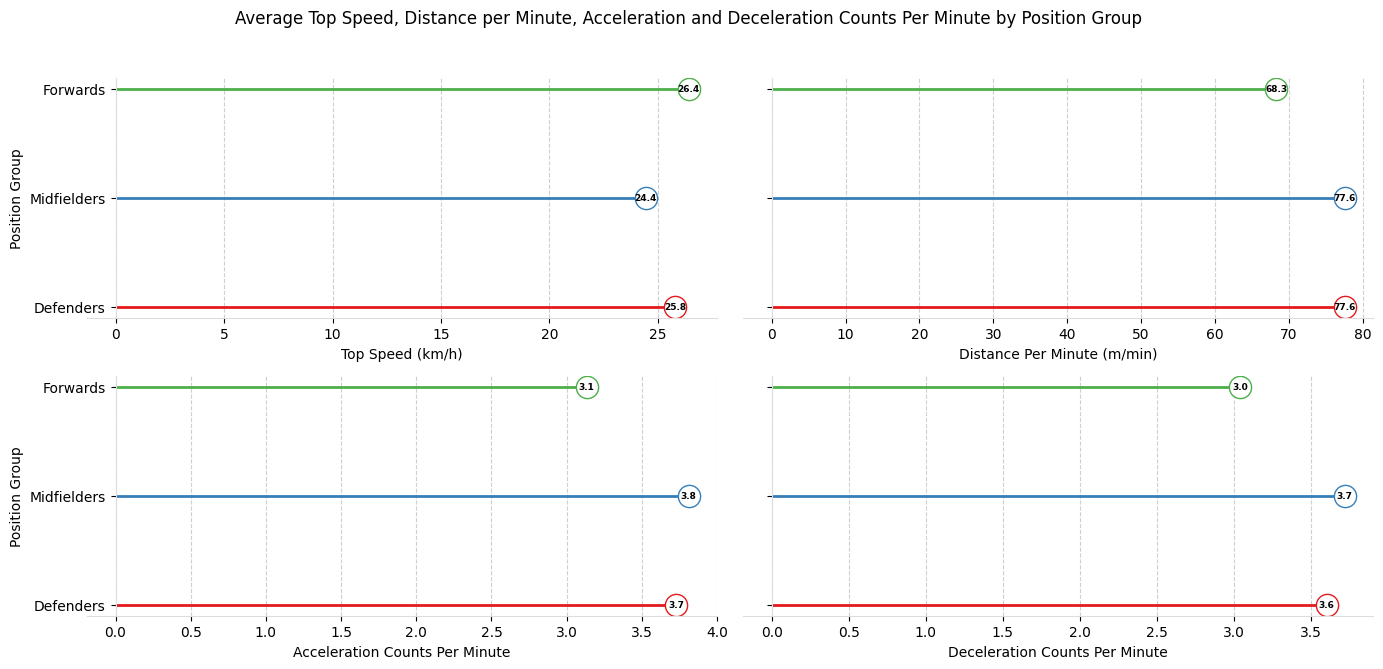

In [33]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('top_speed_kmh', 'Top Speed (km/h)'),
    ('distance_per_min_mmin', 'Distance Per Minute (m/min)'),
    ('acc_counts_per_min', 'Acceleration Counts Per Minute'),
    ('dec_counts_per_min', 'Deceleration Counts Per Minute')
]

# Define the order of position groups
position_order = ['Defenders', 'Midfielders', 'Forwards']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 16

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'top_speed_kmh':
            text_val = f'{val:.1f}'
        elif metric == 'distance_per_min_mmin':
            text_val = f'{val:.1f}'
        elif metric == 'acc_counts_per_min':
            text_val = f'{val:.1f}'
        else:
            text_val = f'{val:.1f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=6.5, color='black', fontweight='bold')

    yticklabels = [f"{pos}" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Top Speed, Distance per Minute, Acceleration and Deceleration Counts Per Minute by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


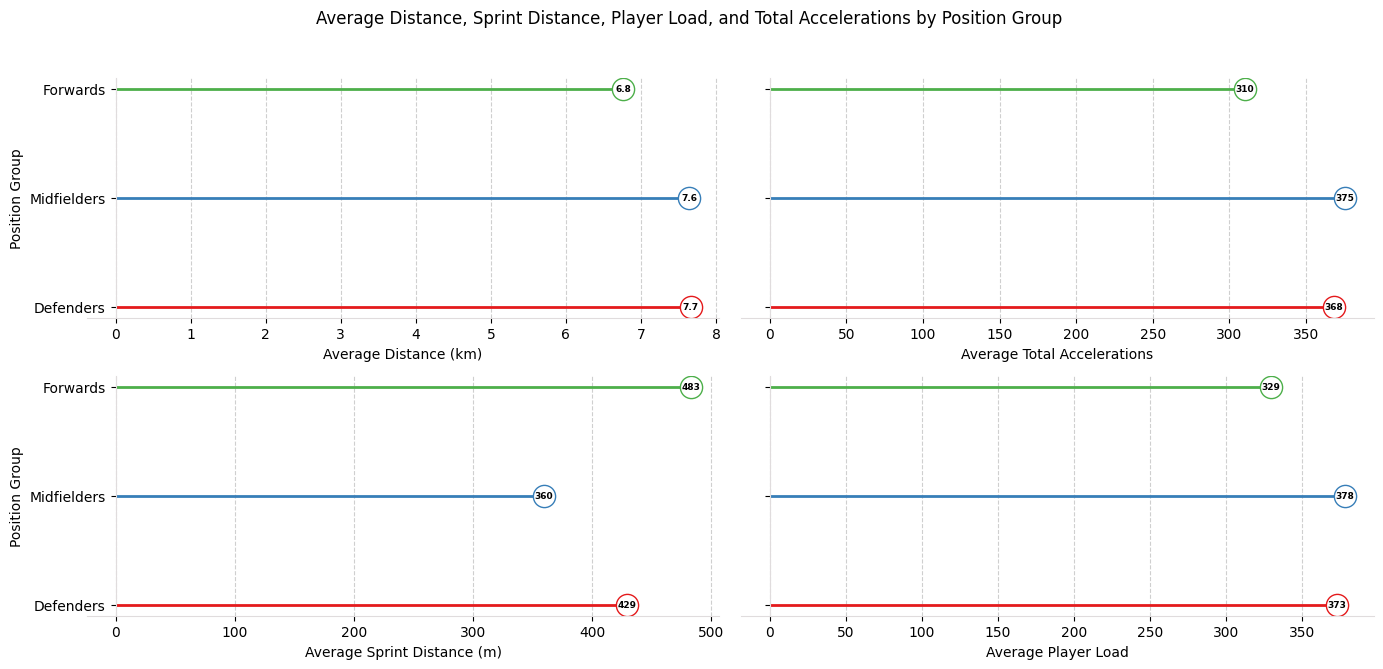

In [34]:
# Draw thin horizontal lines with a large circle at the end for each position group, for four metrics in a 2x2 grid

metrics_to_plot = [
    ('distance_km', 'Average Distance (km)'),
    ('total_accelerations', 'Average Total Accelerations'),
    ('sprint_distance_m', 'Average Sprint Distance (m)'),
    ('player_load', 'Average Player Load')
]

# Define the order of position groups
position_order = ['Defenders', 'Midfielders', 'Forwards']

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

for ax, (metric, xlabel) in zip(axes.flatten(), metrics_to_plot):
    avg_by_position = df.groupby('general_position')[metric].mean().reindex(position_order)
    n = len(avg_by_position)
    y_positions = np.arange(n)
    palette = sns.color_palette('Set1', n)
    circle_radius = 16

    for y, (pos, val), color in zip(y_positions, avg_by_position.items(), palette):
        ax.hlines(y=y, xmin=0, xmax=val, color=color, linewidth=2)
        ax.plot(val, y, 'o', markeredgecolor=color, markersize=circle_radius, markerfacecolor='white')
        if metric == 'distance_km':
            text_val = f'{val:.1f}'
        elif metric == 'sprint_distance_m':
            text_val = f'{val:.0f}'
        elif metric == 'player_load':
            text_val = f'{val:.0f}'
        else:
            text_val = f'{val:.0f}'
        ax.text(val, y, text_val, va='center', ha='center', fontsize=6.5, color='black', fontweight='bold')

    yticklabels = [f"{pos}" for pos in position_order]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(yticklabels, color='#E0DCDD')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('data', 0))
    ax.spines['left'].set_color('#E0DCDD')
    ax.spines['bottom'].set_color('#E0DCDD')

axes[0,0].set_ylabel('Position Group')
axes[1,0].set_ylabel('Position Group')
fig.suptitle('Average Distance, Sprint Distance, Player Load, and Total Accelerations by Position Group')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Comparison by Location

In [35]:
# Calculate average volume metrics by location
avg_volume_by_location = df.groupby('location')[volume_metrics].mean().round(2)
style_table_for_docs(avg_volume_by_location)

,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations
location,,,,,,,
Away,7.450000,424.370000,37.610000,732.150000,5.700000,356.480000,345.900000
Home,7.290000,428.500000,37.390000,723.820000,5.630000,347.450000,337.500000


In [36]:
# Calculate average intensity metrics by location
avg_intensity_by_location = df.groupby('location')[[i for i in intensity_metrics if i not in ['top_speed_kmh','distance_per_min_mmin','max_acceleration_mss','max_deceleration_mss']]].mean()
style_table_for_docs(avg_intensity_by_location)

,player_load,power_score_wkg,work_ratio,acc_counts_per_min,dec_counts_per_min
location,,,,,
Away,363.629390,11.697489,59.672596,3.607261,3.500194
Home,357.236652,11.453861,58.328108,3.520494,3.419775


In [37]:
# Calculate max metrics by location
avg_intensity_by_location_ = df.groupby('location')[['top_speed_kmh','distance_per_min_mmin']].mean().round(2)
style_table_for_docs(avg_intensity_by_location_)

,top_speed_kmh,distance_per_min_mmin
location,,
Away,25.570000,75.410000
Home,25.640000,73.880000


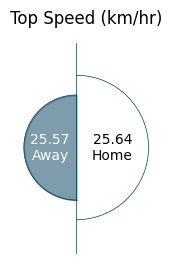

In [38]:
# Prepare data
home_speed = avg_intensity_by_location_.loc['Home', 'top_speed_kmh']
away_speed = avg_intensity_by_location_.loc['Away', 'top_speed_kmh']

# Make radius proportional to top speed (e.g., scale so max speed gets max_radius, min gets min_radius)
min_radius = 0.8
max_radius = 1.1
speeds = np.array([home_speed, away_speed])
norm_radii = min_radius + (speeds - speeds.min()) / (speeds.max() - speeds.min()) * (max_radius - min_radius)
home_radius, away_radius = norm_radii

color = '#003b59'

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect('equal')
ax.axis('off')

# Draw right (Home) semicircle: theta from -pi/2 to pi/2, center at (0,0)
theta_home = np.linspace(-np.pi/2, np.pi/2, 100)
x_home = home_radius * np.cos(theta_home)
y_home = home_radius * np.sin(theta_home)
ax.plot(x_home, y_home, color=color, linewidth=0.5)
if home_radius < away_radius:
    ax.fill_betweenx(y_home, 0, x_home, color=color, alpha=0.5)

# Draw left (Away) semicircle: theta from pi/2 to 3pi/2, center at (0,0)
theta_away = np.linspace(np.pi/2, 3*np.pi/2, 100)
x_away = away_radius * np.cos(theta_away)
y_away = away_radius * np.sin(theta_away)
ax.plot(x_away, y_away, color=color, linewidth=0.5)
if away_radius < home_radius:
    ax.fill_betweenx(y_away, x_away, 0, color=color, alpha=0.5)

# Draw the separating line (y from -max_radius to +max_radius at x=0)
ax.plot([0, 0], [-max(home_radius+0.5, away_radius+0.5), max(home_radius+0.5, away_radius+0.5)], color=color, linewidth=0.5, zorder=3)

# Place values inside semicircles, centered
ax.text(home_radius * 0.5, 0, f"{home_speed:.2f}\nHome", ha='center', va='center', fontsize=10, color='#000', fontweight='normal')
ax.text(-away_radius * 0.5, 0, f"{away_speed:.2f}\nAway", ha='center', va='center', fontsize=10, color='#fff', fontweight='normal')

plt.title('Top Speed (km/hr)', fontsize=12)
plt.show()


### Metric Distribution 

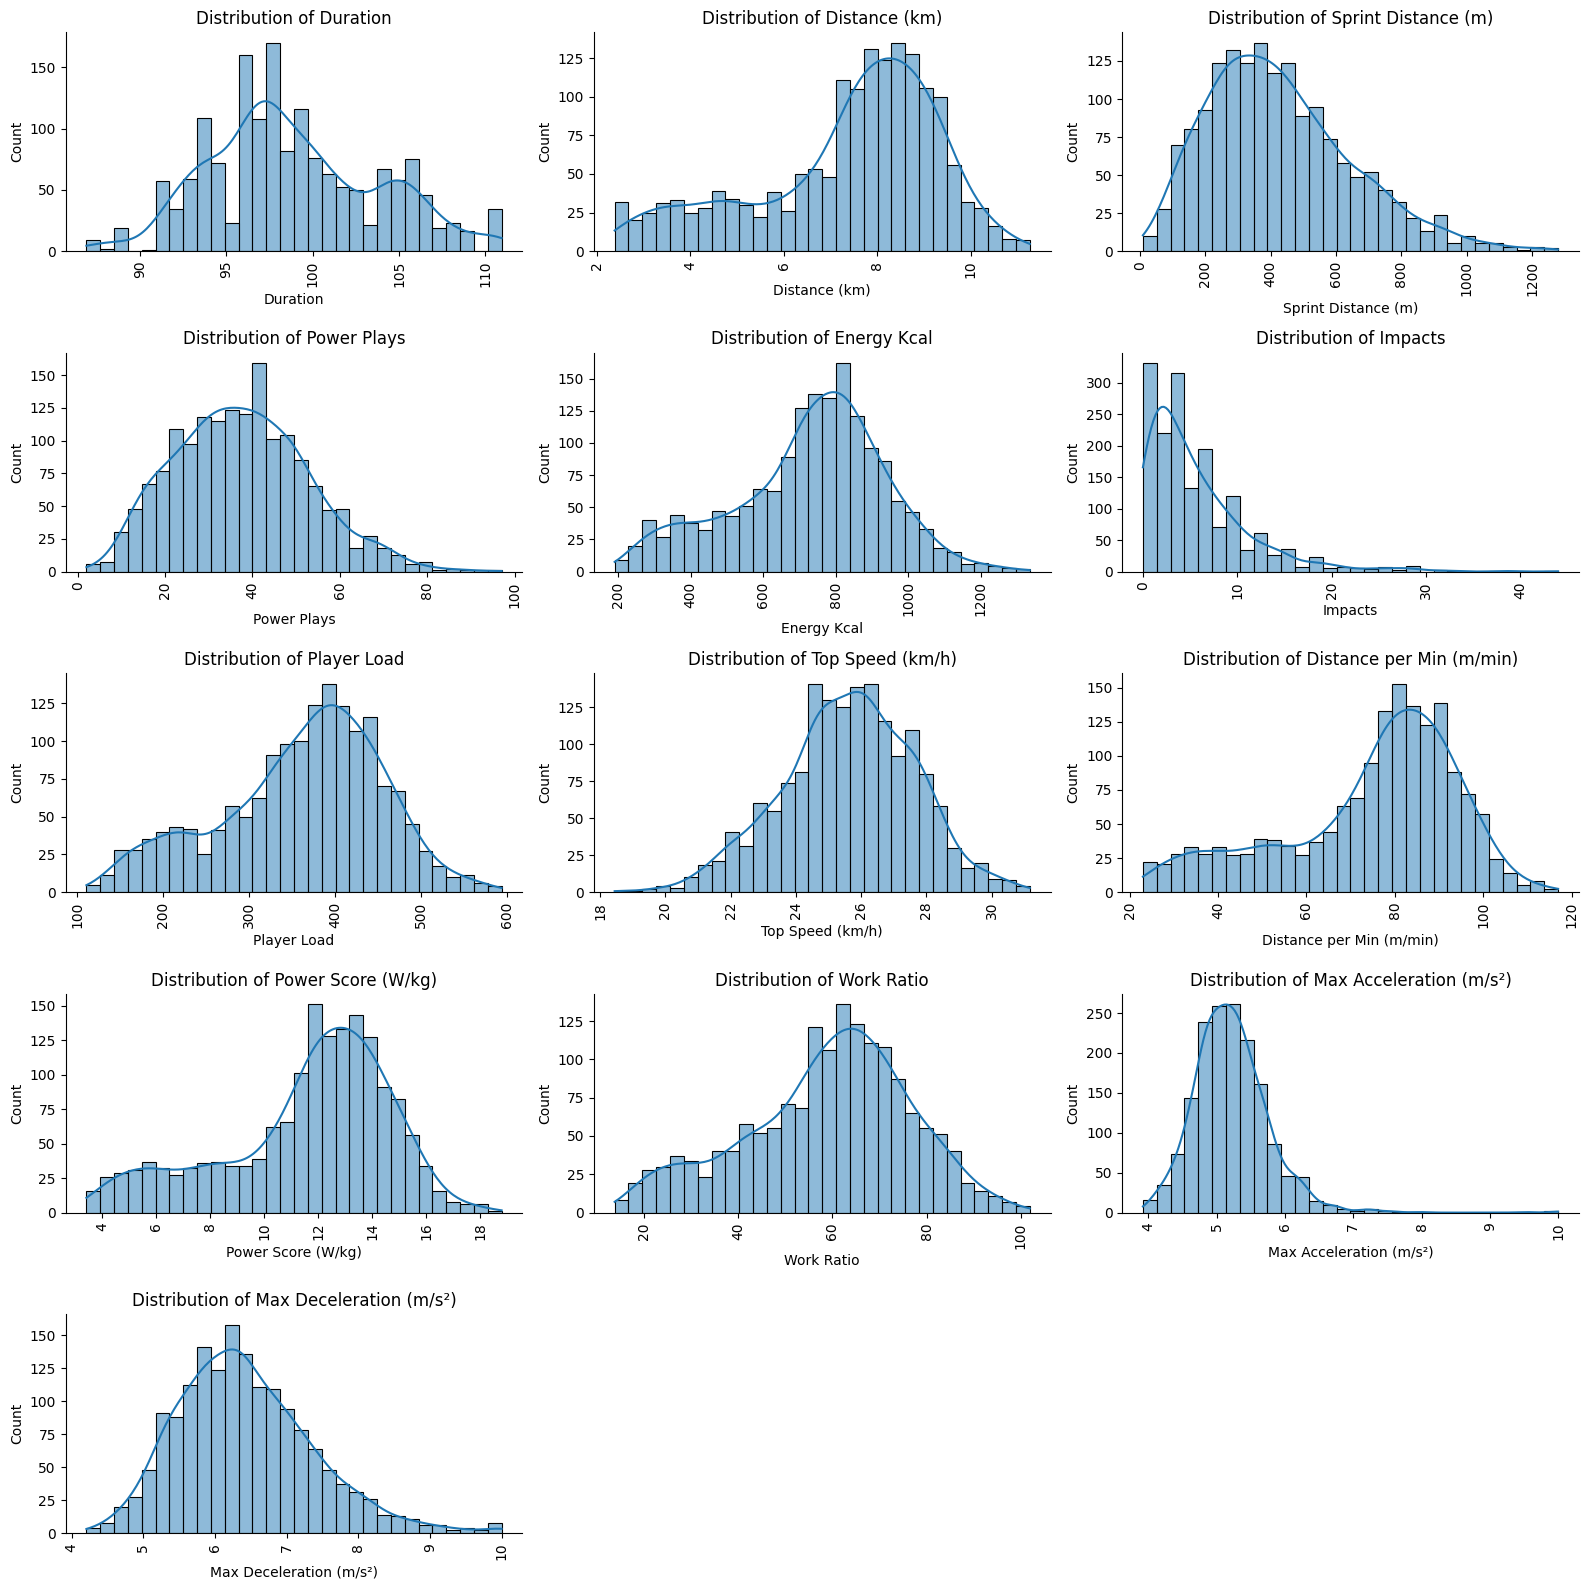

In [39]:
plt.figure(figsize=(16, 16))
for i, col in enumerate(num_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    # Format title and x-label: replace _ with space, capitalize, add units if present
    label = col.replace('_', ' ').title()
    # Add units for specific columns
    if col == 'distance_km':
        label = 'Distance (km)'
    elif col == 'sprint_distance_m':
        label = 'Sprint Distance (m)'
    elif col == 'top_speed_kmh':
        label = 'Top Speed (km/h)'
    elif col == 'distance_per_min_mmin':
        label = 'Distance per Min (m/min)'
    elif col == 'power_score_wkg':
        label = 'Power Score (W/kg)'
    elif col == 'max_acceleration_mss':
        label = 'Max Acceleration (m/s²)'
    elif col == 'max_deceleration_mss':
        label = 'Max Deceleration (m/s²)'
    elif col == 'acc_counts_per_min':
        label = 'Acc. Counts per Min'
    elif col == 'dec_counts_per_min':
        label = 'Dec. Counts per Min'
    
    plt.title(f'Distribution of {label}')
    plt.xlabel(label)
    plt.xticks(rotation=90)
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



In [40]:
# # Comparative bar graph for three leagues using vertical lines with large circles on top

# leagues = [ 'UCL','PSL', 'UPL']
# values = [ 10.94,10.045, 8.54]
# palette = sns.color_palette('Set1', len(leagues))
# circle_radius = 20

# fig, ax = plt.subplots(figsize=(4, 4))

# # Draw vertical lines for each league
# for i, (league, val, color) in enumerate(zip(leagues, values, palette)):
#     ax.vlines(i, 0, val, color=color, linewidth=3, zorder=2)
#     ax.plot(i, val, 'o', markeredgecolor=color, markerfacecolor='white', markersize=circle_radius, zorder=3)
#     ax.text(i, val, f'{val:.1f}', va='top', ha='center', fontweight='bold',fontsize=7, color='black')

# ax.set_xticks(range(len(leagues)))
# ax.set_xticklabels(leagues)
# ax.set_ylabel('Average Total Distance Covered (km)')
# ax.set_xlabel('League')
# ax.set_title('Average Total Distance Covered by Players in Different Leagues', fontsize=11, fontweight='bold')
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_color('#E0DCDD')
# ax.spines['bottom'].set_color('#E0DCDD')
# ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=1)
# plt.tight_layout()
# plt.show()

## Trend Analysis

In [41]:
avg_volume_per_matchday = df.groupby('match_day')[volume_metrics + intensity_metrics].mean().reset_index()
# Ensure 'match_day' is a categorical variable with the correct order
avg_volume_per_matchday['match_day'] = pd.Categorical(
    avg_volume_per_matchday['match_day'],
    categories=matchday_order,
    ordered=True
)
avg_volume_per_matchday = avg_volume_per_matchday.sort_values(by='match_day').round(2)
style_table_for_docs(avg_volume_per_matchday)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,MD1,6.960000,348.880000,32.300000,687.380000,5.580000,346.910000,335.010000,343.950000,25.130000,71.050000,11.010000,56.850000,5.120000,6.150000,3.540000,3.420000
11,MD2,7.100000,392.410000,34.890000,699.780000,5.380000,346.810000,335.230000,352.280000,25.410000,68.980000,10.730000,54.960000,5.150000,6.420000,3.380000,3.270000
15,MD3,7.370000,440.240000,40.400000,738.660000,6.650000,364.790000,355.850000,364.280000,25.440000,76.180000,11.790000,60.940000,5.280000,6.520000,3.770000,3.680000
16,MD4,7.260000,429.240000,36.580000,716.330000,5.680000,346.610000,337.690000,351.870000,25.520000,74.070000,11.500000,59.140000,5.280000,6.510000,3.540000,3.450000
17,MD5,7.270000,411.030000,37.660000,719.440000,6.080000,360.750000,349.190000,359.030000,25.680000,73.030000,11.240000,56.810000,5.550000,6.430000,3.620000,3.500000
18,MD6,7.100000,395.570000,35.940000,699.520000,4.070000,340.930000,328.380000,342.880000,25.420000,72.890000,11.290000,58.040000,5.140000,6.290000,3.500000,3.370000
19,MD7,7.470000,430.710000,37.410000,731.980000,6.190000,358.620000,346.770000,362.860000,25.690000,75.920000,11.730000,59.630000,5.230000,6.500000,3.650000,3.530000
20,MD8,7.430000,411.870000,37.620000,727.380000,5.050000,371.060000,361.740000,367.030000,25.080000,75.590000,11.780000,60.590000,4.960000,6.180000,3.770000,3.680000
21,MD9,7.230000,436.330000,38.220000,725.830000,5.340000,337.720000,329.120000,342.340000,25.940000,76.860000,11.910000,60.890000,5.160000,6.600000,3.590000,3.500000
1,MD10,7.390000,395.000000,35.590000,729.500000,5.330000,352.130000,342.890000,355.180000,25.450000,74.010000,11.460000,58.130000,5.200000,6.480000,3.520000,3.430000


In [42]:
# Sort by match_day using the correct order
df['match_day'] = pd.Categorical(df['match_day'], categories=matchday_order, ordered=True)
df_sorted = df.sort_values('match_day')

# Compute rolling mean for each metric per match day
rolling_avg = (
    df_sorted.groupby('match_day', observed=True)[volume_metrics + intensity_metrics]
    .mean()
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index()
)

rolling_avg['match_day'] = pd.Categorical(rolling_avg['match_day'], categories=matchday_order, ordered=True)
rolling_avg = rolling_avg.sort_values(by='match_day').round(2)
style_table_for_docs(rolling_avg)

,match_day,distance_km,sprint_distance_m,power_plays,energy_kcal,impacts,total_accelerations,total_decelerations,player_load,top_speed_kmh,distance_per_min_mmin,power_score_wkg,work_ratio,max_acceleration_mss,max_deceleration_mss,acc_counts_per_min,dec_counts_per_min
0,MD1,6.960000,348.880000,32.300000,687.380000,5.580000,346.910000,335.010000,343.950000,25.130000,71.050000,11.010000,56.850000,5.120000,6.150000,3.540000,3.420000
1,MD2,7.030000,370.640000,33.590000,693.580000,5.480000,346.860000,335.120000,348.120000,25.270000,70.020000,10.870000,55.900000,5.140000,6.280000,3.460000,3.340000
2,MD3,7.140000,393.840000,35.860000,708.610000,5.870000,352.840000,342.030000,353.500000,25.320000,72.070000,11.180000,57.580000,5.180000,6.360000,3.560000,3.450000
3,MD4,7.240000,420.630000,37.290000,718.260000,5.900000,352.740000,342.920000,356.140000,25.450000,73.080000,11.340000,58.350000,5.240000,6.480000,3.560000,3.460000
4,MD5,7.300000,426.840000,38.210000,724.810000,6.140000,357.380000,347.580000,358.390000,25.540000,74.430000,11.510000,58.970000,5.370000,6.490000,3.640000,3.540000
5,MD6,7.210000,411.940000,36.730000,711.760000,5.280000,349.430000,338.420000,351.260000,25.540000,73.330000,11.350000,58.000000,5.320000,6.410000,3.550000,3.440000
6,MD7,7.280000,412.430000,37.000000,716.980000,5.450000,353.430000,341.450000,354.920000,25.600000,73.950000,11.420000,58.160000,5.310000,6.410000,3.590000,3.470000
7,MD8,7.330000,412.720000,36.990000,719.630000,5.100000,356.870000,345.630000,357.590000,25.400000,74.800000,11.600000,59.420000,5.110000,6.320000,3.640000,3.530000
8,MD9,7.380000,426.300000,37.750000,728.400000,5.530000,355.800000,345.880000,357.410000,25.570000,76.120000,11.810000,60.370000,5.120000,6.430000,3.670000,3.570000
9,MD10,7.350000,414.400000,37.140000,727.570000,5.240000,353.640000,344.580000,354.850000,25.490000,75.490000,11.720000,59.870000,5.110000,6.420000,3.630000,3.540000


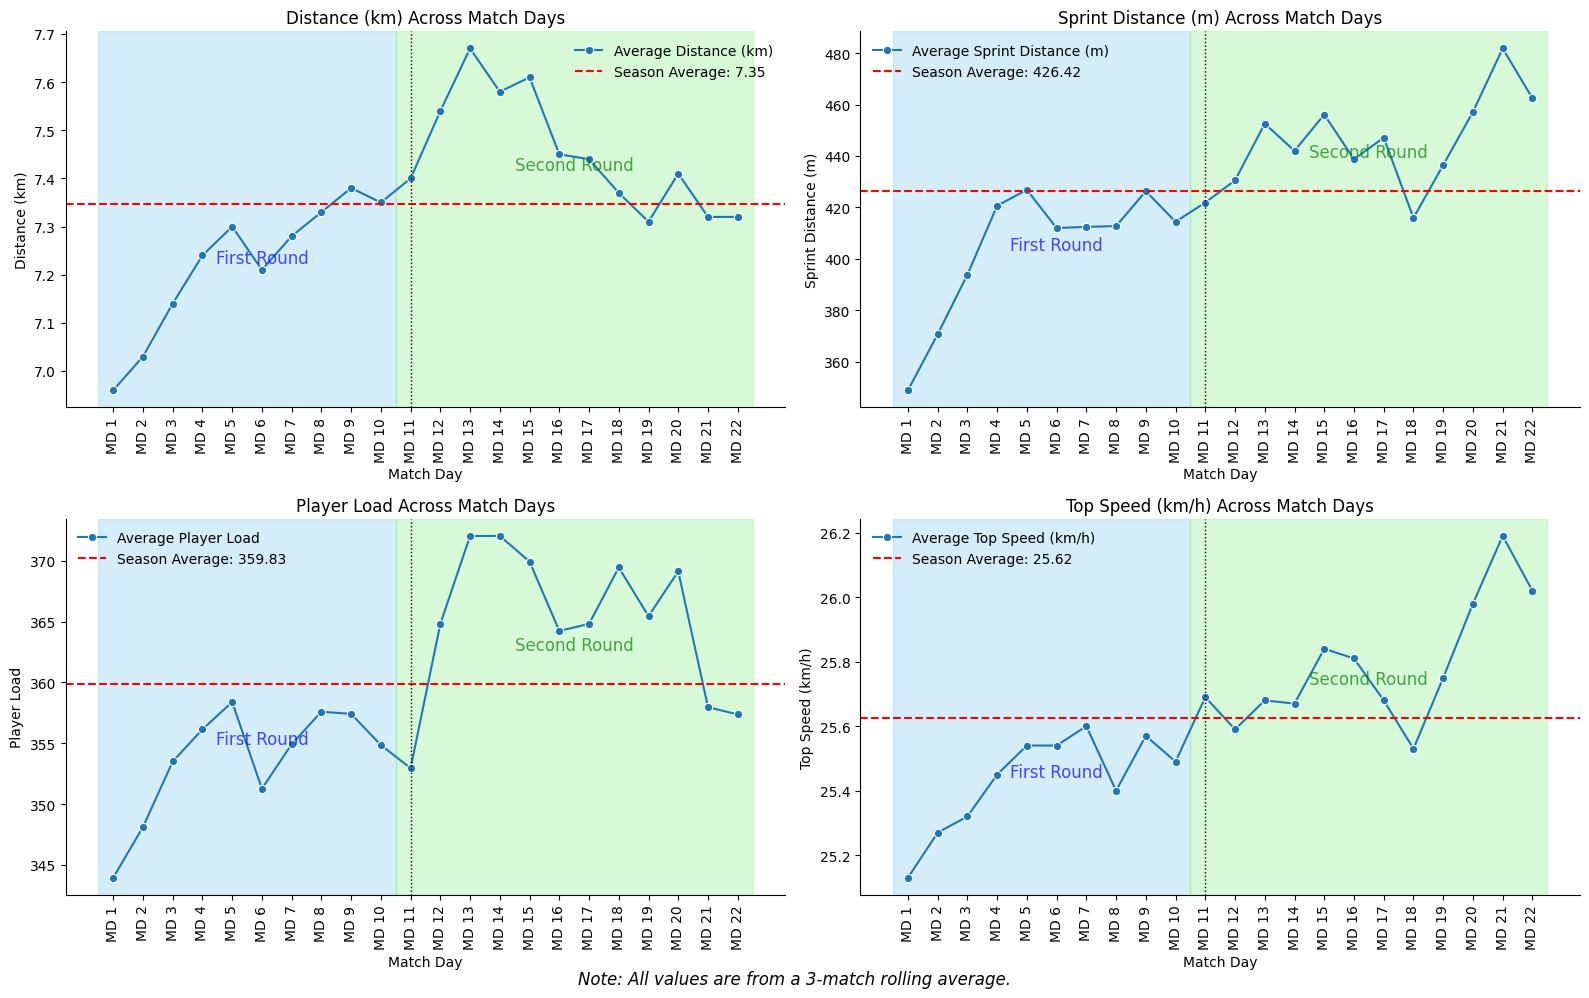

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = [
    ('distance_km', 'Distance (km)'),
    ('sprint_distance_m', 'Sprint Distance (m)'),
    ('player_load', 'Player Load'),
    ('top_speed_kmh', 'Top Speed (km/h)')
]

# Get valid match days (non-NaN)
valid_matchdays = rolling_avg['match_day'].dropna().tolist()
MD11_idx = valid_matchdays.index('MD11') if 'MD11' in valid_matchdays else None
last_idx = len(valid_matchdays) - 1

for ax, (col, label) in zip(axes.flatten(), metrics):
    sns.lineplot(
        data=rolling_avg,
        x='match_day',
        y=col,
        marker='o',
        ax=ax,
        label=f'Average {label}'
    )
    avg_value = rolling_avg[col].mean()
    ax.axhline(avg_value, color='red', linestyle='--', label=f'Season Average: {avg_value:.2f}')
    # Draw vertical line at MD11
    ax.axvline(MD11_idx, color='black', linestyle=':', linewidth=1)
    # Shade area before MD11 (First Round)
    ax.axvspan(-0.5, MD11_idx - 0.5, color='skyblue', alpha=0.35)
    # Shade area from MD11 to last matchday (Second Round)
    ax.axvspan(MD11_idx - 0.5, last_idx + 0.5, color='lightgreen', alpha=0.35)
    xticklabels = [str(Wmd).replace('MD', 'MD ') for Wmd in valid_matchdays]
    ax.set_xticks(range(len(valid_matchdays)))
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_title(f'{label} Across Match Days')
    ax.set_xlabel('Match Day')
    ax.set_ylabel(label)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    legend = ax.legend(frameon=False)
    ymin, ymax = ax.get_ylim()
    ax.text(MD11_idx/2, avg_value - (ymax-ymin)*0.12, 'First Round', color='blue', fontsize=12, ha='center', va='top', alpha=0.7)
    ax.text(MD11_idx + (last_idx-MD11_idx)/2, avg_value + (ymax-ymin)*0.08, 'Second Round', color='green', fontsize=12, ha='center', va='bottom', alpha=0.7)

plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.figtext(0.5, 0.01, "Note: All values are from a 3-match rolling average.", ha='center', fontsize=12, style='italic')
plt.show()


## Correlation Analysis

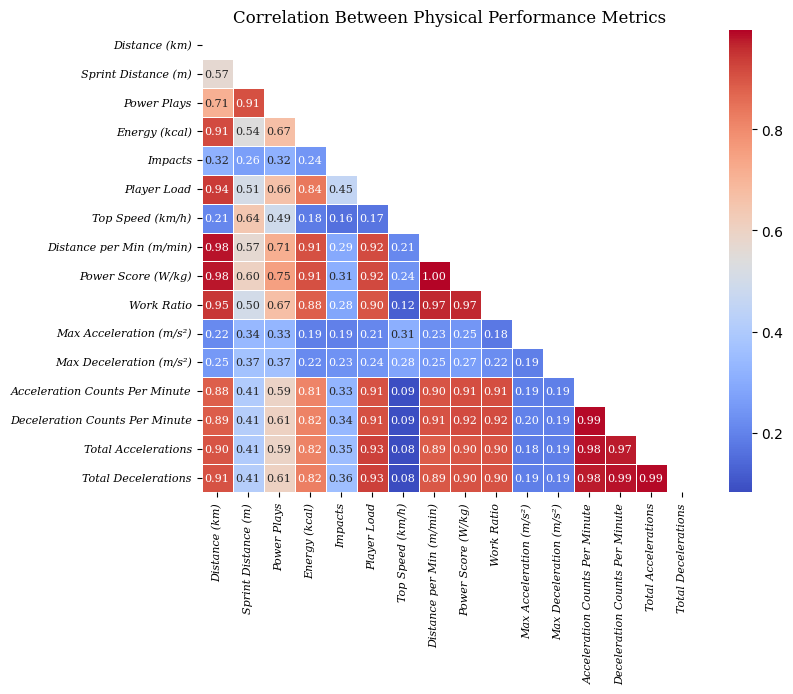

In [44]:
cols_to_corr = [col for col in num_cols if col != 'duration']
cols_to_corr.extend(['acc_counts_per_min','dec_counts_per_min','total_accelerations','total_decelerations'])
corr = df[cols_to_corr].corr(method='pearson')

# Mapping for pretty axis labels
pretty_labels = {
    'distance_km': 'Distance (km)',
    'sprint_distance_m': 'Sprint Distance (m)',
    'power_plays': 'Power Plays',
    'energy_kcal': 'Energy (kcal)',
    'impacts': 'Impacts',
    'player_load': 'Player Load',
    'top_speed_kmh': 'Top Speed (km/h)',
    'distance_per_min_mmin': 'Distance per Min (m/min)',
    'power_score_wkg': 'Power Score (W/kg)',
    'work_ratio': 'Work Ratio',
    'max_acceleration_mss': 'Max Acceleration (m/s²)',
    'max_deceleration_mss': 'Max Deceleration (m/s²)',
    'acc_counts_per_min':'Acceleration Counts Per Minute',
    'dec_counts_per_min':'Deceleration Counts Per Minute',
    'total_accelerations': 'Total Accelerations',
    'total_decelerations': 'Total Decelerations'
}

# Re-label the correlation matrix
corr = corr.rename(index=pretty_labels, columns=pretty_labels)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    annot_kws={"fontsize":8, "fontfamily":"serif"}
)
plt.title("Correlation Between Physical Performance Metrics", fontsize=12, fontfamily="serif")
plt.xticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.yticks(fontsize=8, fontfamily="serif", fontstyle="italic")
plt.show()


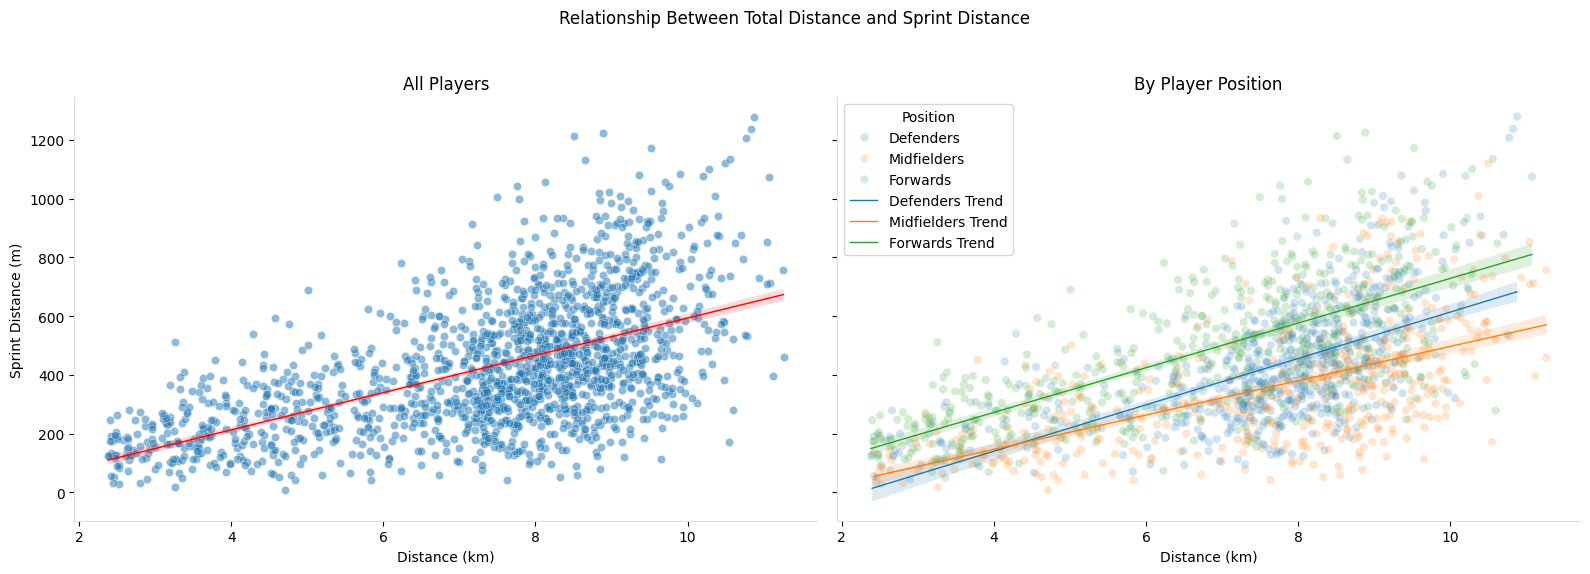

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: All players, no hue
ax1 = axes[0]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', alpha=0.5, ax=ax1)
sns.regplot(data=df, x='distance_km', y='sprint_distance_m', scatter=False, ax=ax1, color='red', line_kws={'linewidth':1})
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Sprint Distance (m)')
ax1.set_title('All Players')
ax1.grid(False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#E0DCDD')
ax1.spines['bottom'].set_color('#E0DCDD')

# Plot 2: Hue by player position, trend lines for each group
ax2 = axes[1]
sns.scatterplot(data=df, x='distance_km', y='sprint_distance_m', hue='general_position', alpha=0.2, ax=ax2)
for pos in df['general_position'].dropna().unique():
    sns.regplot(
        data=df[df['general_position'] == pos],
        x='distance_km',
        y='sprint_distance_m',
        scatter=False,
        ax=ax2,
        label=f"{pos} Trend",
        line_kws={'linewidth':1}
    )
ax2.set_xlabel('Distance (km)')
ax2.set_ylabel('Sprint Distance (m)')
ax2.set_title('By Player Position')
ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#E0DCDD')
ax2.spines['bottom'].set_color('#E0DCDD')
ax2.legend(title='Position')

plt.suptitle('Relationship Between Total Distance and Sprint Distance')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()